In [1]:
import numpy as np
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from Plot import make_yref, set_spines_and_ticks_width, save_figure_incremental

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


/tmp/ipykernel_130646/3424259692.py:21: RuntimeWarning: Mean of empty slice.
  force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/nump

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response_15.svg


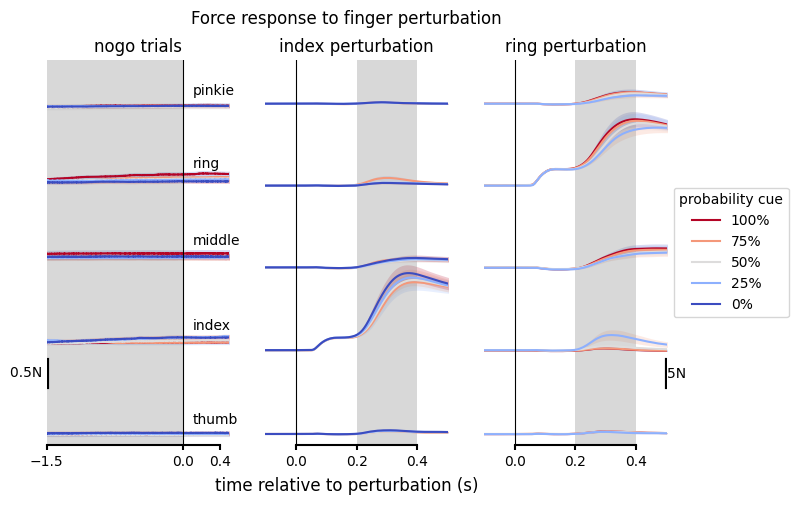

In [12]:
experiment = 'smp2'

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir,'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

fig, axs = plt.subplots(ncols=3, figsize=(8,5))

vsep_go = 15
vsep_nogo = 1.5

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        if stimF != 'nogo':
            axs[sf].set_title(f'{stimF} perturbation')
        else:
            axs[sf].set_title('nogo trials')
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            if (sf==2) & (f==0):
                axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[4-c],  label=cue)
            else:
                axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[4-c])
            axs[sf].fill_between(tAx, force_avg + f * vsep_go - force_err, force_avg + f * vsep_go + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[0].plot(tAx, force_avg + f * vsep_nogo, color=list(gl.colour_mapping.values())[4-c])
            axs[0].fill_between(tAx, force_avg + f * vsep_nogo - force_err, force_avg + f * vsep_nogo + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for f, finger in enumerate(descr.finger.unique()):
    force_avg = force[(descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
    force_err = force[(descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
    axs[0].text(.1, force_avg.mean() + f * vsep_nogo + force_err.mean() + .1, finger, va='bottom', ha='left')


axs[0].axvspan(-1.5, 0, color='grey', alpha=.3, lw=0)
axs[1].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
axs[2].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
axs[0].set_xlim([-1.5, .5])
axs[1].set_xlim([-.1, .5])
axs[2].set_xlim([-.1, .5])
axs[0].set_ylim([-.21, 6.90])
axs[1].set_ylim([-2, 68])
axs[2].set_ylim([-2, 68])

axs[0].set_xticks([-1.5, 0, .4])
axs[1].set_xticks([0, .2, .4])
axs[2].set_xticks([0, .2, .4])

make_yref(axs[2], reference_length=5, pos='right')
make_yref(axs[0], reference_length=.5, pos='left')

axs[0].spines[['bottom',]].set_bounds(-1.5, .4)
axs[1].spines[['bottom',]].set_bounds(0, .4)
axs[2].spines[['bottom',]].set_bounds(0, .4)

axs[2].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='probability cue')

for ax in axs:
    set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])

fig.suptitle('Force response to finger perturbation')
fig.supxlabel('time relative to perturbation (s)')

save_figure_incremental(fig, 'force_response')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response_binned_6.svg


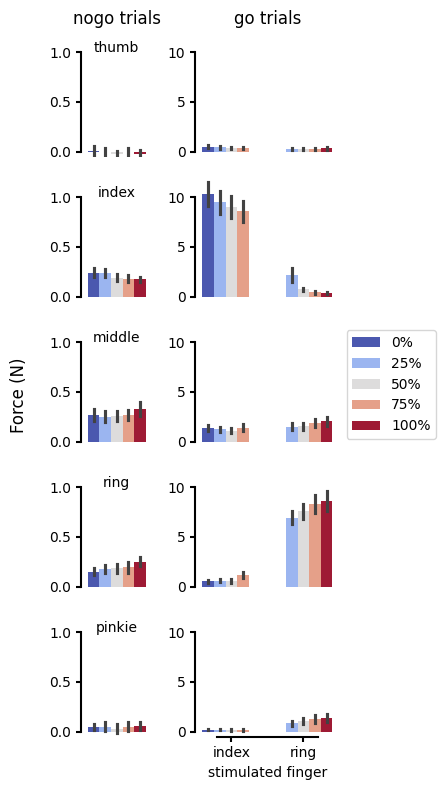

In [3]:
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(5, 2, figsize=(4.5, 8), gridspec_kw={'width_ratios': [1, 2]})

for f, finger in enumerate(gl.channels['mov']):
    if f==2:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=True, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')
    else:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=False, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 1].set_ylim([-.5, 12])
    axs[f, 1].set_xlabel('')
    axs[f, 1].set_ylabel('')
    # axs[f, 1].set_title(finger)
    axs[f, 1].spines[['left',]].set_bounds(0, 10)

    if f<4:
        axs[f, 1].set_xticks([])
        axs[f, 1].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 1].set_title(f'go trials')

for f, finger in enumerate(gl.channels['mov']):
    sns.barplot(x='stimFinger', y=finger + '0', ax=axs[f, 0], hue='cue', data=df[df['GoNogo']=='nogo'], legend=False, hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 0].set_ylim([-.05, 1.2])
    axs[f, 0].set_xlabel('')
    axs[f, 0].set_ylabel('')
    axs[f, 0].text(0, 1, finger, ha='center')
    axs[f, 0].spines[['left',]].set_bounds(0, 1)

    axs[f, 0].set_xticks([])
    axs[f, 0].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 0].set_title(f'nogo trials')

axs[-1, -1].set_xlabel('stimulated finger')
axs[-1, -1].spines[['right','top']].set_visible(False)
axs[-1, -1].spines[['bottom',]].set_bounds(-.2, 1.2)
axs[2, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5), )

for row in range(5):
    for col in range(2):
        set_spines_and_ticks_width(axs[row, col], spine_width=1.5,spine_sides=('bottom', 'left'), tick_width=1.5,axes=('x', 'y'),which='both')

fig.supylabel('Force (N)')
fig.tight_layout()

save_figure_incremental(fig, 'force_response_binned')

In [4]:
# Retrieve emg data
channels = ['thumb_flex',
        'index_flex',
        'middle_flex',
        'ring_flex',
        'pinkie_flex',
        'thumb_ext',
        'index_ext',
        'middle_ext',
        'ring_ext',
        'pinkie_ext',
        'fdi']

participant_ids = ['subj100',
                   'subj101',
                   'subj102',
                   'subj103',
                   'subj104',
                   'subj105',
                   'subj106',
                   'subj107',
                   'subj108',
                   'subj109',
                   'subj110']


experiment = 'smp0'
path = os.path.join(gl.baseDir, experiment)
participants = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')

cue_code = [93, 12, 44, 21, 39]
stimFinger_code = [91999, 99919]

latency = pd.read_csv(os.path.join(gl.baseDir, 'smp0', 'clamped', 'smp0_clamped_latency.tsv'), sep='\t')
latency = latency['index'][0], latency['ring'][0]

Dict = {ch: [] for ch in channels}
for participant in participant_ids:

    sn = int(''.join([c for c in participant if c.isdigit()]))

    print(f'loading {participant}...')
    emg = np.load(os.path.join(path, 'emg',participant,  f'{experiment}_{sn}.npy'))
    dat = pd.read_csv(os.path.join(path, gl.behavDir, participant, f'{experiment}_{sn}.dat'), sep='\t')
    blocks = [int(b) for b in participants[participants['sn'] == sn].blocks_emg.iloc[0].split('.')]
    dat = dat[dat.BN.isin(blocks)]
    ch_p = participants[participants['sn'] == sn].channels_emg.iloc[0].split(',')

    for ch in Dict.keys():
        if ch in ch_p:
            idx = ch_p.index(ch)
            emg_av = np.zeros((len(cue_code), len(stimFinger_code), emg.shape[-1]))
            for sf, stimF in enumerate(stimFinger_code):
                for c, cue in enumerate(cue_code):
                    emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)

            Dict[ch].append(emg_av)


loading subj100...


/tmp/ipykernel_130646/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj101...


/tmp/ipykernel_130646/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj102...


...

/tmp/ipykernel_130646/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj109...


/tmp/ipykernel_130646/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


loading subj110...


/tmp/ipykernel_130646/2210308454.py:55: RuntimeWarning: Mean of empty slice.
  emg_av[c, sf] = emg[(dat.cue == cue) & (dat.stimFinger == stimF), idx].mean(axis=0)
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


/tmp/ipykernel_130646/3645661818.py:21: RuntimeWarning: Mean of empty slice
  y = np.nanmean(np.array(Dict[ch]), axis=0) + c * .1
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_130646/3645661818.py:21: RuntimeWarning: Mean of empty slice
  y = np.nanmean(np.array(Dict[ch]), axis=0) + c * .1
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/EMG_response_12.svg


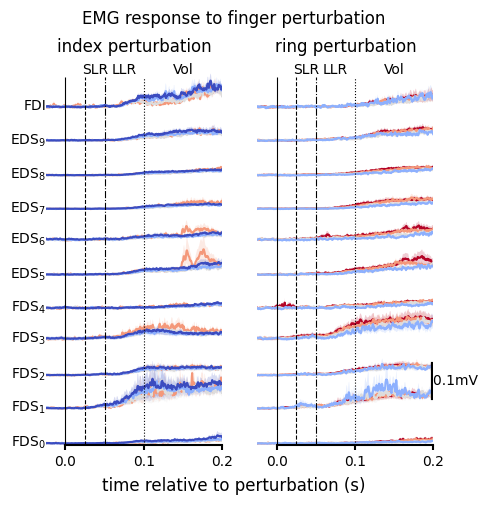

In [11]:
from matplotlib.lines import Line2D
from Plot import make_yref

# Time axis for each latency
tAx = [np.linspace(-1, 2, emg.shape[-1]) - l for l in latency]

# Set up plot
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(5, 5))
palette = list(gl.colour_mapping.values())[:5][::-1]
labels = ['0%', '25%', '50%', '75%', '100%']

# Vertical lines and associated styles
line_xs = [0, .025, .05, .1]
line_styles = ['-', '--', '-.', ':']
line_labels = ['SLR', 'LLR', 'Vol']

for sf, (stimF, ax) in enumerate(zip(['index', 'ring'], axs)):
    ax.set_title(f'{stimF} perturbation')

    for c, ch in enumerate(channels):
        y = np.nanmean(np.array(Dict[ch]), axis=0) + c * .1
        yerr = np.nanstd(np.array(Dict[ch]), axis=0) / np.sqrt(len(participants))

        if sf == 0:
            label = (f'FDS$_{{{c}}}$' if c < 5 else
                     f'EDS$_{{{c}}}$' if c < 10 else
                     'FDI' if c == 10 else '')
            ax.text(-.025, np.nanmean(y[:, 0, 0]), label, va='center', ha='right')

        for col, color in enumerate(palette):
            ax.plot(tAx[sf], y[col, sf], color=color)
            ax.fill_between(tAx[sf], y[col, sf] - yerr[col, sf], y[col, sf] + yerr[col, sf],
                            color=color, lw=0, alpha=.2)

    ax.set_xlim([-.025, .2])
    ax.set_ylim([0, 1.15])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Remove y-ticks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    # Draw vertical lines
    for x, style in zip(line_xs, line_styles):
        ax.vlines(x, ymin=0, ymax=1.1, linestyles=style, color='k', lw=.8)

    ax.spines['bottom'].set_bounds([0, .2])
    set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes=('x', ),which='both')

    # Place text labels between key vertical lines
    xlims = ax.get_xlim()
    text_positions = [
        (.025 + .05) / 2,          # "SLR"
        (.05 + .1) / 2,            # "LLR"
        (.1 + xlims[1]) / 2        # "Vol"
    ]
    for label, xpos in zip(line_labels, text_positions):
        ax.text(xpos, 1.1, label, ha='center', va='bottom')

# # Custom legend at the bottom (single row), with more space
# handles = [Line2D([0], [0], color=color) for color in palette]
# fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=False,columnspacing=1.0,  # tighter spacing between items
#     handlelength=1.2,   # shorter line in legend
#     handletextpad=0.4)   # reduce space between line and text)

# Global labels and layout
fig.supxlabel('time relative to perturbation (s)')
fig.suptitle('EMG response to finger perturbation')
# fig.supylabel('EMG (mV)')

make_yref(axs[1], reference_length=.1, pos='right', unit='mV')

save_figure_incremental(fig, 'EMG_response')

# Adjust layout to avoid overlap
# fig.tight_layout(rect=[0, 0., 1, 1])  # Leaves extra space at bottom
plt.show()
